In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("Country-data.csv")

In [5]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (167, 10)


In [7]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [8]:

df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [9]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


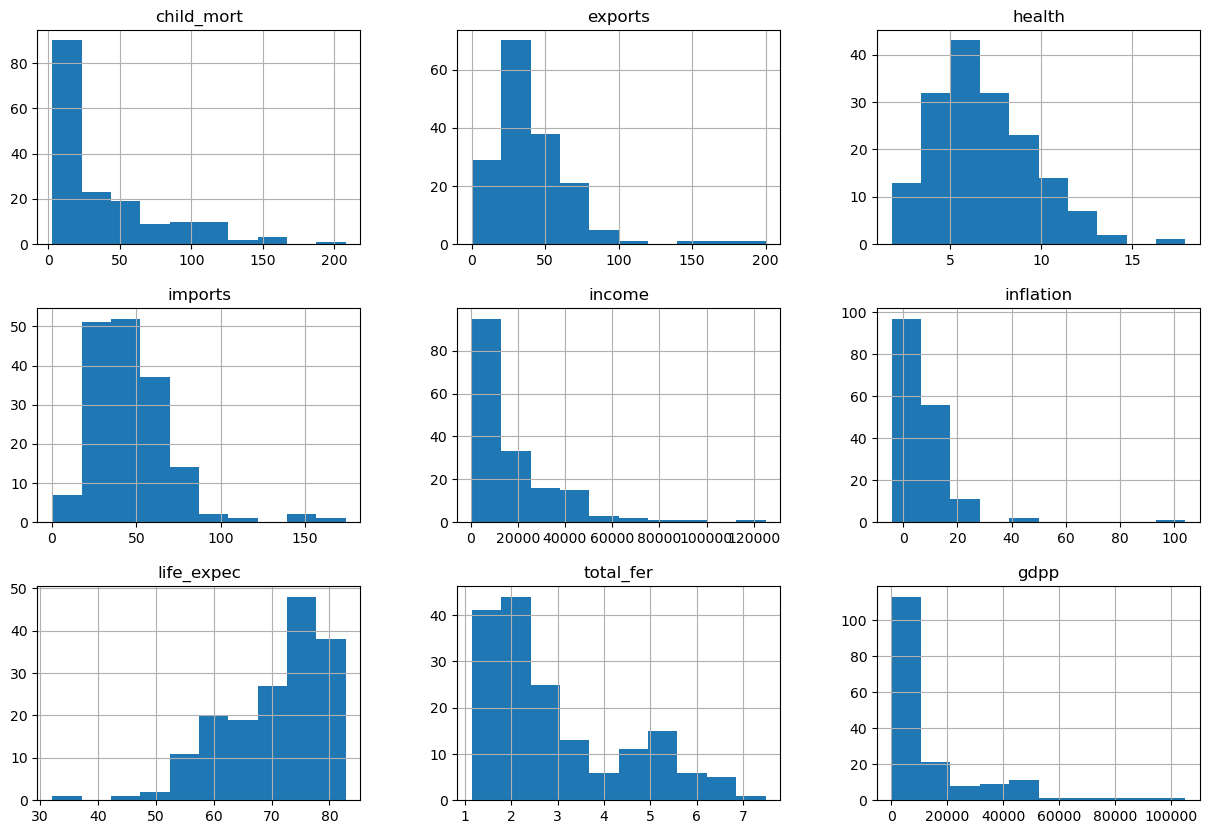

In [12]:
df.hist(figsize=(15,10))

plt.show()

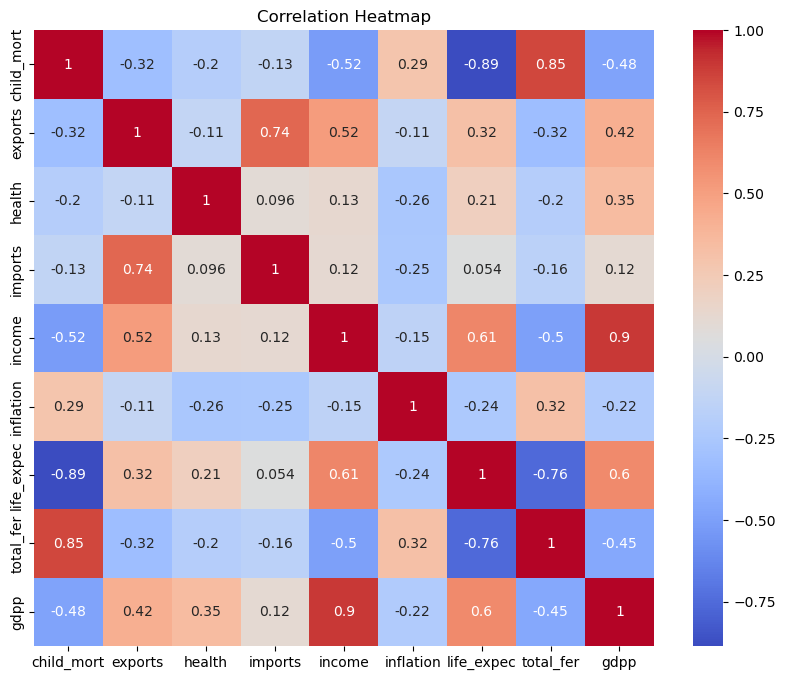

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

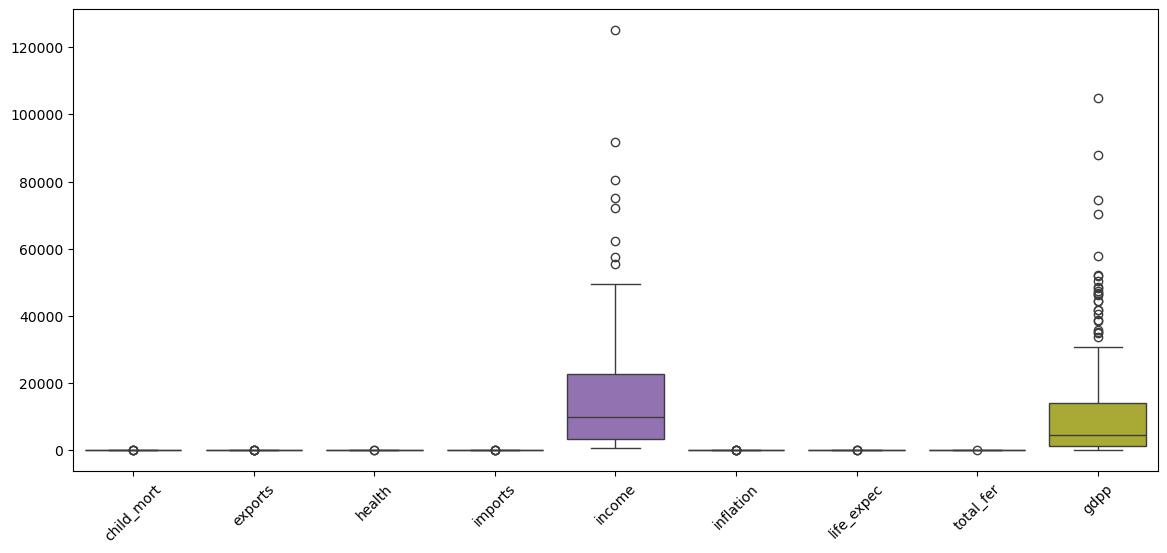

In [14]:
#boxplot

plt.figure(figsize=(14,6))

sns.boxplot(data=df.drop("country",axis=1))

plt.xticks(rotation=45)

plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

X = df.drop("country", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


In [16]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    model = KMeans(n_clusters=i, random_state=42)

    model.fit(X_scaled)

    wcss.append(model.inertia_)

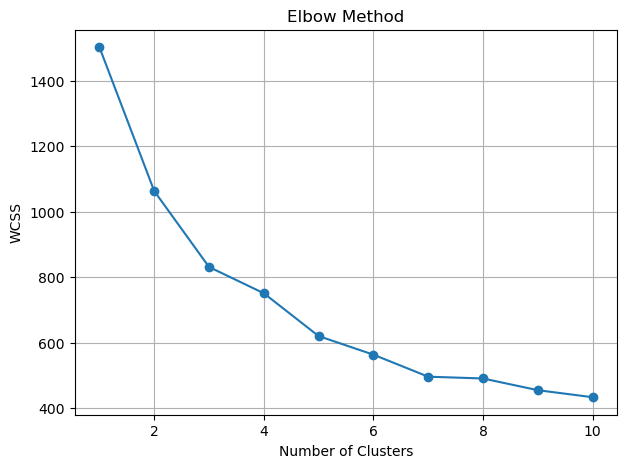

In [17]:
plt.figure(figsize=(7,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

In [20]:
df["Cluster"] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [21]:
df["Cluster"].value_counts()

Cluster
0    86
2    45
1    36
Name: count, dtype: int64

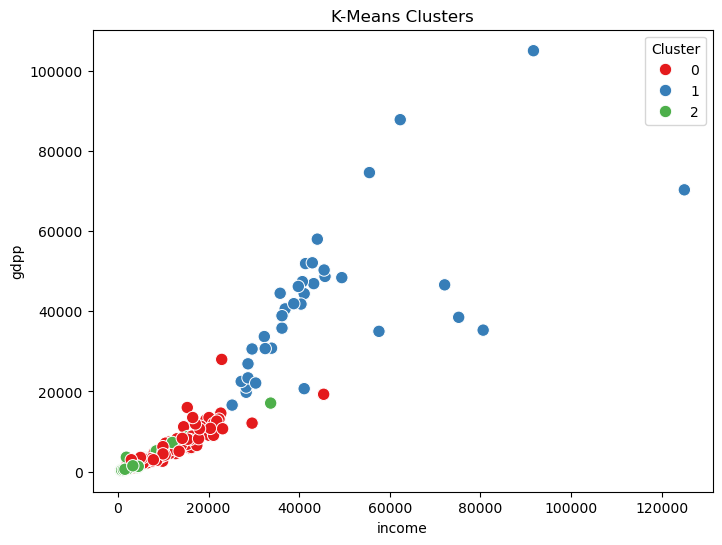

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="income",
    y="gdpp",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("K-Means Clusters")

plt.show()

In [23]:
df.groupby("Cluster").mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


In [25]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

df[["country", "DBSCAN_Cluster"]].head()

,country,DBSCAN_Cluster
0,Afghanistan,-1
1,Albania,0
2,Algeria,-1
3,Angola,-1
4,Antigua and Barbuda,0


In [26]:
df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
-1    146
 0      9
 1      7
 2      5
Name: count, dtype: int64

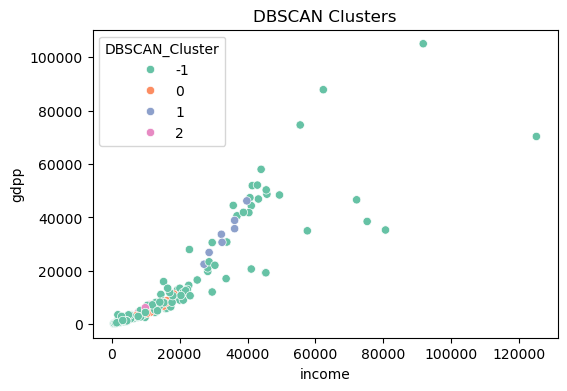

In [27]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x="income",
    y="gdpp",
    hue="DBSCAN_Cluster",
    palette="Set2"
)

plt.title("DBSCAN Clusters")

plt.show()

In [28]:
X = df.drop(["country", "Cluster"], axis=1)

# Target
y = df["Cluster"]

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 1.0


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


In [32]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(random_state=42)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)

ada_acc = accuracy_score(y_test, ada_pred)

print("AdaBoost Accuracy:", ada_acc)

AdaBoost Accuracy: 1.0


In [33]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 1.0


In [34]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    random_state=42,
    verbose=-1
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

lgbm_acc = accuracy_score(y_test, lgbm_pred)

print("LightGBM Accuracy :", lgbm_acc)

LightGBM Accuracy : 1.0


In [35]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        dt_acc,
        rf_acc,
        xgb_acc
    ]
})

results

,Model,Accuracy
0,Decision Tree,1.0
1,Random Forest,1.0
2,XGBoost,1.0


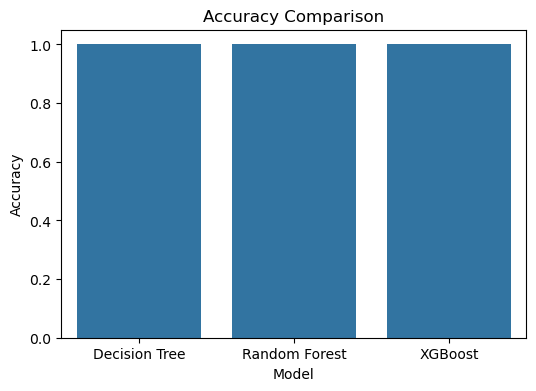

In [36]:
plt.figure(figsize=(6,4))

sns.barplot(data=results, x="Model", y="Accuracy")

plt.title("Accuracy Comparison")

plt.show()

In [37]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
0,child_mort,0.299712
8,gdpp,0.181798
7,total_fer,0.151194
6,life_expec,0.148386
4,income,0.148051
2,health,0.029026
1,exports,0.017923
5,inflation,0.014321
3,imports,0.009317
9,DBSCAN_Cluster,0.000273


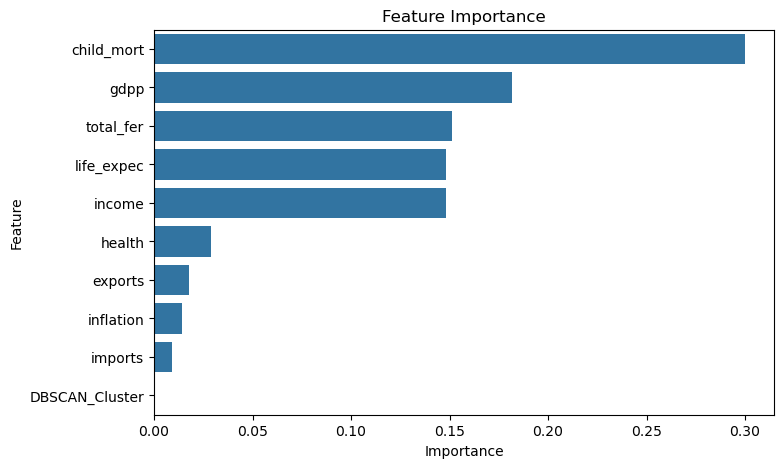

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [39]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

cm = confusion_matrix(y_test, rf_pred)

print(cm)

[[20  0  0]
 [ 0  8  0]
 [ 0  0  6]]


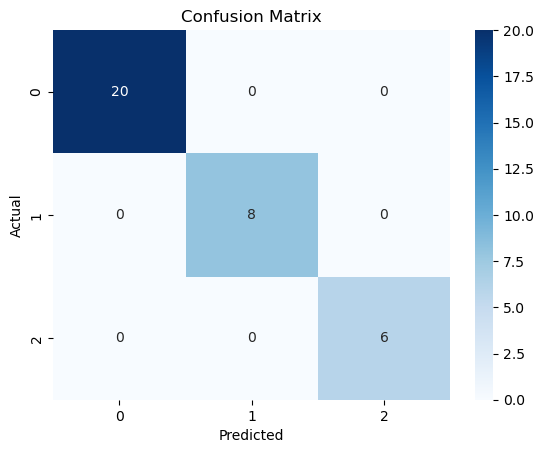

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [40]:
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

print(classification_report(y_test, rf_pred))

Final Insights
Cluster 0 consists of high-income and high-GDP countries with high life expectancy and low child mortality. These countries are economically developed and have better healthcare and living standards.
Cluster 1 contains underdeveloped countries characterized by high child mortality, low income, low GDP per capita, and lower life expectancy. These countries face significant socioeconomic and healthcare challenges.
Cluster 2 represents developing or emerging economies with moderate income, GDP, and health indicators. These countries are in transition and perform better than underdeveloped nations but still lag behind developed countries.
Countries in the underdeveloped cluster should be prioritized for international aid and development programs, as they exhibit poor economic conditions, inadequate healthcare, and high child mortality. Examples include countries such as Afghanistan, Burundi, Chad, Niger, Sierra Leone, and the Central African Republic (depending on your clustering results).
The clustering analysis successfully groups countries with similar socioeconomic characteristics, making it easier for governments and international organizations to identify priority regions, allocate resources efficiently, and formulate targeted development policies.